Prosjektoppgave

Oppgave Del a)
      u_dag  kl_slett  varighet  score
0    Mandag  08:04:16  00:07:12    NaN
1    Mandag  08:04:53  00:02:49    6.0
2    Mandag  08:06:31  00:08:36    NaN
3    Mandag  08:11:21  00:04:34    NaN
4    Mandag  08:20:46  00:07:38    NaN
..      ...       ...       ...    ...
212  Fredag  15:06:52  00:11:12    NaN
213  Fredag  15:25:32  00:10:21    NaN
214  Fredag  15:30:39  00:07:16    NaN
215  Fredag  15:39:11  00:08:49    NaN
216  Fredag  15:56:10  00:10:13   10.0

[217 rows x 4 columns]
 
Oppgave Del b)
 
    Ukedag  Antall
0   Mandag      51
1  Tirsdag      44
2   Onsdag      45
3  Torsdag      35
4   Fredag      42


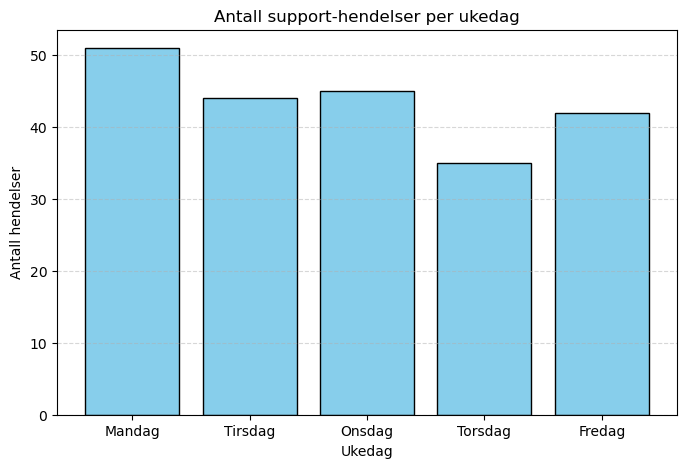

Oppgave Del c)
 
Minste samtaletid i uke 24:  00:00:59
Lengste samtaletid i uke 24:  00:11:28
 
  
Oppgave Del d)
 
Gjennomsnittlig samtaletid i uke 24: 00:06:40
 
Oppgave del e)
 
tidsrom
08–10    98
10–12    40
12–14    45
14–16    34
Name: count, dtype: int64


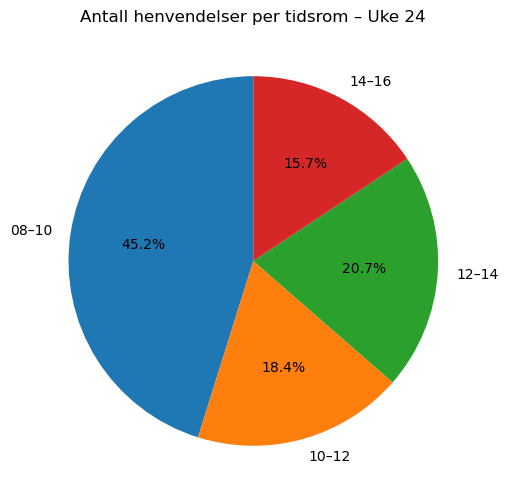

 
Oppgave del f)
 
Antall promoters: 28
Antall detractors: 10
Totalt antall svar: 43
NPS-score: 41.9


In [58]:

import pandas as pd
import matplotlib.pyplot as plt

#---------------------------------------------------------------------------
# Oppgave del a)

filnavn = "support_uke_24.xlsx"

# Innlesing av filen
data = pd.read_excel(filnavn)

# Endre kolonne navn til navnene som krever i oppgaven
data.rename(columns={
    "Ukedag": "u_dag",
    "Klokkeslett": "kl_slett",
    "Varighet": "varighet",
    "Tilfredshet": "score"
}, inplace=True)

print("Oppgave Del a)")
print(data)
print(" ")


#---------------------------------------------------------------------------
# Oppgave del b)

#Telle hvor mange ganger hver ukedag forekommer
# og deler opp i kolonne
ukedager = data["u_dag"].value_counts().reset_index()
ukedager.columns = ["Ukedag", "Antall"]

#sortere ukedager i rekkerfølge
rekkefølge = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]
ukedager = ukedager.set_index("Ukedag").reindex(rekkefølge).reset_index()

print("Oppgave Del b)")
print(" ")
print(ukedager)

plt.figure(figsize=(8,5))
plt.bar(ukedager["Ukedag"], ukedager["Antall"], color="skyblue", edgecolor="black")

plt.xlabel("Ukedag")
plt.ylabel("Antall hendelser")
plt.title("Antall support-hendelser per ukedag")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


#---------------------------------------------------------------------------
# Oppgave del c)

print("Oppgave Del c)")
print(" ")
print("Minste samtaletid i uke 24: ", data["varighet"].agg(["min", "max"])["min"])
print("Lengste samtaletid i uke 24: ", data["varighet"].agg(["min", "max"])["max"])
print(" ")


#---------------------------------------------------------------------------
# Oppgave del d)

# Gjennomsnitt i sekunder
gj_snitt_sek = pd.to_timedelta(data["varighet"]).dt.total_seconds().mean()

# Konvertere tilbake til HH:MM:SS
hhmmss = pd.to_timedelta(gj_snitt_sek, unit="s")
hhmmss = str(str(hhmmss).split()[-1].split(".")[0])
print("  ")
print("Oppgave Del d)")
print(" ")
print("Gjennomsnittlig samtaletid i uke 24:", hhmmss)


#---------------------------------------------------------------------------
# Oppgave del e)

print(" ")
print("Oppgave del e)")
print(" ")


# Gjør kl_slett om til datetime (selv om dato mangler)
data["kl_slett"] = pd.to_datetime(data["kl_slett"], format="%H:%M:%S")

# Hent timeverdien
data["time"] = data["kl_slett"].dt.hour

# Definer 2-timers intervaller
bins = [8, 10, 12, 14, 16]
labels = ["08–10", "10–12", "12–14", "14–16"]

data["tidsrom"] = pd.cut(data["time"], bins=bins, labels=labels, right=False)

# Tell antall henvendelser per tidsrom
antall_per_tidsrom = data["tidsrom"].value_counts().sort_index()
print(antall_per_tidsrom)

# Lag sektordiagram
plt.figure(figsize=(6,6))
plt.pie(
    antall_per_tidsrom,
    labels=antall_per_tidsrom.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Antall henvendelser per tidsrom – Uke 24")
plt.show()


#---------------------------------------------------------------------------
# Oppgave del f)

print(" ")
print("Oppgave del f)")
print(" ")


# Fjern rader uten score
nps_data = data.dropna(subset=["score"])

# Tell grupper
antall_promoters = (nps_data["score"] >= 9).sum()
antall_detractors = (nps_data["score"] <= 6).sum()
antall_total = len(nps_data)

# Beregn NPS
nps = ((antall_promoters - antall_detractors) / antall_total) * 100

print("Antall promoters:", antall_promoters)
print("Antall detractors:", antall_detractors)
print("Totalt antall svar:", antall_total)
print("NPS-score:", round(nps, 1))

